# Householder's reflectors.

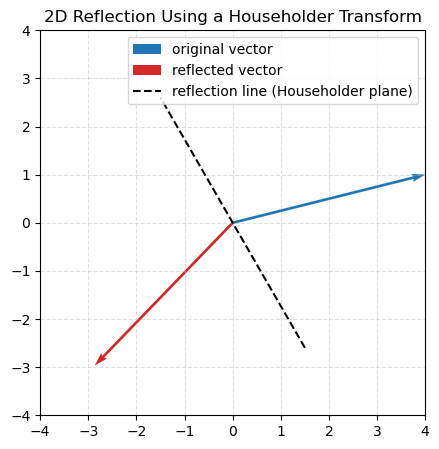

In [41]:
import numpy as np
import matplotlib.pyplot as plt


theta = np.pi / 6 # setting up line of reflection.
n = np.array([np.cos(theta), np.sin(theta)]) # unit normal vector.

# Householder's reflection in 2D
H = np.eye(2) - 2 * np.outer(n, n)
v = np.array([4,1])
v_ref = H @ v

plt.figure(figsize=(5,5))
plt.grid(True, linestyle='--', alpha=0.4)
plt.gca().set_aspect('equal', adjustable='box')

# Draw original vector
plt.quiver(0,0, v[0], v[1], angles='xy', scale_units='xy', scale=1,
           color='tab:blue', width=0.007, label="original vector")

# Draw reflected vector
plt.quiver(0,0, v_ref[0], v_ref[1], angles='xy', scale_units='xy', scale=1,
           color='tab:red', width=0.007, label="reflected vector")

# Draw the line of reflection (perpendicular to n)
d = np.array([-n[1], n[0]])  # direction vector along reflection line
t = np.linspace(-3,3,100)
x_line = t * d[0]
y_line = t * d[1]
plt.plot(x_line, y_line, 'k--', label='reflection line (Householder plane)')

plt.xlim(-4,4)
plt.ylim(-4,4)
plt.title("2D Reflection Using a Householder Transform")
plt.legend()
plt.show()

## Using Householder's reflectors to 0 out the vector's components

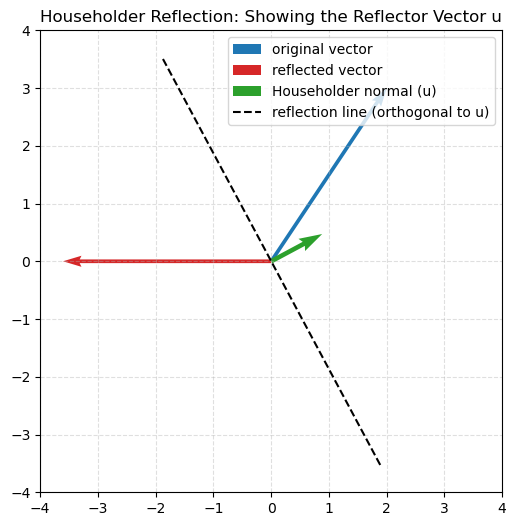

In [42]:
x = np.array([2,3])
v = x
norm_x = np.linalg.norm(x)

sign = 1.0 if x[0] > 0 else -1.0 # for numerical stability
e = np.array([1.0, 0])
u = x + sign * norm_x * e
u = u / np.linalg.norm(u)

H = np.eye(2) - 2 * np.outer(u, u)
v_ref = H @ v

# reflection plane
d = np.array([-u[1], u[0]])

# Plotting
plt.figure(figsize=(6,6))
plt.grid(True, linestyle='--', alpha=0.4)
plt.gca().set_aspect('equal', adjustable='box')

# Original vector
plt.quiver(0, 0, v[0], v[1], angles='xy', scale_units='xy',
           scale=1, color='tab:blue', width=0.008, label="original vector")

# Reflected vector
plt.quiver(0, 0, v_ref[0], v_ref[1], angles='xy', scale_units='xy',
           scale=1, color='tab:red', width=0.008, label="reflected vector")

# Householder normal vector (u)
plt.quiver(0, 0, u[0], u[1], angles='xy', scale_units='xy',
           scale=1, color='tab:green', width=0.01, label="Householder normal (u)")

# Reflection line (perpendicular to u)
t = np.linspace(-4,4,100)
plt.plot(t * d[0], t * d[1], 'k--', label="reflection line (orthogonal to u)")

plt.xlim(-4, 4)
plt.ylim(-4, 4)
plt.title("Householder Reflection: Showing the Reflector Vector u")
plt.legend()
plt.show()

# QR decomposition using householder's reflectors

In [47]:
def qr_householder(A, tol=1e-12):
    A = np.array(A, copy=True,dtype=np.float64)
    m,n = A.shape
    Q = np.eye(m)
    R = A.copy()
    for k in range(min(m,n)):

        #Extracting the vector to reflect
        x = R[k:, k]
        norm_x = np.linalg.norm(x)
        if norm_x == 0:
            continue

        # choosing a sign for numerical stability ( for floating point cancellations)
        sign = 1.0 if x[0] > 0 else -1.0

        # building the householder reflection vector
        v = x.copy()
        v[0] += sign * norm_x
        v_norm = np.linalg.norm(v)
        v = v / v_norm
        # Forming householder's transformationm
        Hk = np.eye(m-k) - 2.0 * np.outer(v,v)
        R[k:, :] = Hk @ R[k:, :]

        H_full = np.eye(m)
        H_full[k:, k:] = Hk
        Q = Q @ H_full

    return Q, R


In [52]:
# Testing code :

A = np.array( [[1,-1,4],[1,4,-2],[1,4,2],[1,-1,0]])
Q, R = qr_householder(A)

print("Q:\n", np.round(Q,2))
print("R:\n", np.round(R,2))




Q:
 [[-0.5  0.5 -0.5 -0.5]
 [-0.5 -0.5  0.5 -0.5]
 [-0.5 -0.5 -0.5  0.5]
 [-0.5  0.5  0.5  0.5]]
R:
 [[-2. -3. -2.]
 [ 0. -5.  2.]
 [-0. -0. -4.]
 [-0.  0.  0.]]


In [51]:
np.random.seed(37)
A = np.random.randint(1,10,size=(4,3))
#A = np.array(A, dtype=np.float64, copy=True)
print("A:\n" , np.round(A,2))

Qg, Rg = qr_householder(A)
print("QR decomposition using Householder's")
print("Qg:\n", np.round(Qg,2))
print("Rg:\n", np.round(Rg,2))
print("Qg x Rg:\n", np.round(Qg @ Rg,2))
print("Qg x Qg.T")
print(np.round(Qg @ Qg.T,2))


A:
 [[6 7 4]
 [4 6 9]
 [6 8 9]
 [9 4 3]]
QR decomposition using Householder's
Qg:
 [[-0.46 -0.3   0.77  0.34]
 [-0.31 -0.43 -0.61  0.59]
 [-0.46 -0.47 -0.14 -0.74]
 [-0.69  0.71 -0.15  0.01]]
Rg:
 [[-13.   -11.54 -10.85]
 [ -0.    -5.64  -7.24]
 [ -0.     0.    -4.12]
 [ -0.    -0.     0.  ]]
Qg x Rg:
 [[6. 7. 4.]
 [4. 6. 9.]
 [6. 8. 9.]
 [9. 4. 3.]]
Qg x Qg.T
[[ 1. -0. -0. -0.]
 [-0.  1. -0.  0.]
 [-0. -0.  1. -0.]
 [-0.  0. -0.  1.]]
